# Testing MALAT1 x KRT18 co-localisation as a negative control
- L(r) values should be well within the envelope
    - Our null here is checking gene label-specific interaction 
    - The permutation envelope shows bounds for the gene label being non-significant
- MALAT is uniquitous and KRT18 is present in specific structures
    - This means they should have high L(r) values 
    - (KRT18 is in certain cells, MALAT1 is in all cells, so there will be singicant co-occurance)

### Set up

In [26]:
%run 03_K_function.ipynb

[     0.           1308.00621227   4708.82236418   9156.04348591
  18312.08697181  28514.53542753  36975.30551339  48224.15893893
  59377.39213931  74157.86233798  85537.51638475  98231.90583249
 110148.20586797 122749.10346653 134184.69152303 149006.67302698
 162609.93763461 174865.48140308 185373.61367123 200009.50123384
 215364.20223718 230358.69329909 243406.98077993 260347.86305106
 277490.24975631 292885.10408525 305060.1575666  319471.4878077
 337211.79071075 354770.28742253 370280.84626248 386036.98431549
 403031.30204302 423236.90791912 439062.78563215 455131.78564549
 467409.50721515 483835.3873139  499116.11504779 513221.17367225
 527966.49221325 542380.66816151 555104.73012668 567894.30150383
 581820.96864569 596748.9781732  611455.79211165 626066.32129522
 640704.96264178 655769.37948847 669278.89784652 679563.91266332
 692676.67629545 703486.26023645 716580.41088065 731949.62665487
 744254.065039   755939.88320781 769521.42085875 781017.50139864]
bivariate_k output shape:

In [27]:
%%capture

import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
import time

fov3 = pd.read_parquet("../data/processed/fov3_strips.parquet")

GENE_A = 'MALAT1'
GENE_B = 'KRT18'
R_MAX = 250           
N_R = 50             
N_SIM = 99          
SEED = 42

r_vals = np.linspace(0, R_MAX, N_R)


  Processing strip_2


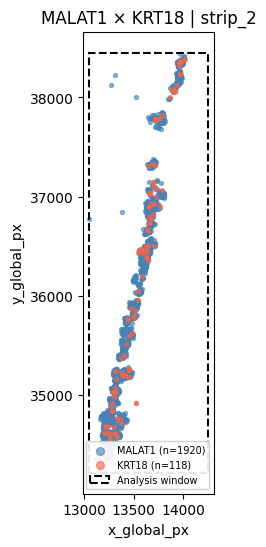

  MALAT1: 1920 transcripts
  KRT18: 118 transcripts
  Window: x=[13052, 14252], y=[34219, 38450]
  Narrowest dimension: 1200 px
  R_MAX = 250 px (21% of narrow dim)
  Observed L(r) computed in 0.2s
    L(r=50): 120.40
    L(r=100): 170.46
    L(r=200): 205.10
  Computing 99-simulation envelope (this will take ~24s)...
  Envelope computed in 25.1s

  Processing strip_3


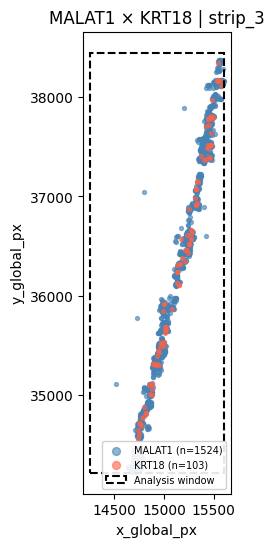

  MALAT1: 1524 transcripts
  KRT18: 103 transcripts
  Window: x=[14254, 15605], y=[34219, 38448]
  Narrowest dimension: 1351 px
  R_MAX = 250 px (19% of narrow dim)
  Observed L(r) computed in 0.2s
    L(r=50): 149.13
    L(r=100): 197.20
    L(r=200): 222.56
  Computing 99-simulation envelope (this will take ~17s)...
  Envelope computed in 16.3s


In [28]:
DIAGNOSTICS = True

results = {}

for strip_name in ['strip_2', 'strip_3']:
    print(f"\n{'='*60}")
    print(f"  Processing {strip_name}")
    print(f"{'='*60}")
    
    strip_df = fov3[fov3['strip'] == strip_name]
    
    coords_a = get_coords(strip_df, GENE_A)
    coords_b = get_coords(strip_df, GENE_B)
    window   = get_window(strip_df)
    
    if DIAGNOSTICS:
        plot_diagnostics(coords_a, coords_b, window,
                     gene_a=GENE_A, gene_b=GENE_B,
                     title=f'{GENE_A} × {GENE_B} | {strip_name}')
        plt.show()

    n_a, n_b = len(coords_a), len(coords_b)
    narrow_dim = min(window[1] - window[0], window[3] - window[2])
    
    print(f"  {GENE_A}: {n_a} transcripts")
    print(f"  {GENE_B}: {n_b} transcripts")
    print(f"  Window: x=[{window[0]:.0f}, {window[1]:.0f}], "
          f"y=[{window[2]:.0f}, {window[3]:.0f}]")
    print(f"  Narrowest dimension: {narrow_dim:.0f} px")
    print(f"  R_MAX = {R_MAX} px ({R_MAX/narrow_dim*100:.0f}% of narrow dim)")
    
    # --- Observed L(r) ---
    t0 = time.time()
    k_obs = bivariate_k(coords_a, coords_b, r_vals, window)
    l_obs = k_to_l(k_obs, r_vals)
    t_obs = time.time() - t0
    print(f"  Observed L(r) computed in {t_obs:.1f}s")
    
    # Spot-check
    for r_check in [50, 100, 200]:
        idx = np.argmin(np.abs(r_vals - r_check))
        print(f"    L(r={r_check}): {l_obs[idx]:.2f}")
    
    # --- Permutation envelope ---
    print(f"  Computing {N_SIM}-simulation envelope (this will take ~{t_obs * N_SIM:.0f}s)...")
    t0 = time.time()
    l_lo, l_hi = compute_envelope(coords_a, coords_b, r_vals, window,
                                   n_sim=N_SIM, seed=SEED)
    t_env = time.time() - t0
    print(f"  Envelope computed in {t_env:.1f}s")
    
    # Store everything
    results[strip_name] = {
        'coords_a': coords_a,
        'coords_b': coords_b,
        'window': window,
        'k_obs': k_obs,
        'l_obs': l_obs,
        'l_lo': l_lo,
        'l_hi': l_hi,
        'n_a': n_a,
        'n_b': n_b,
    }

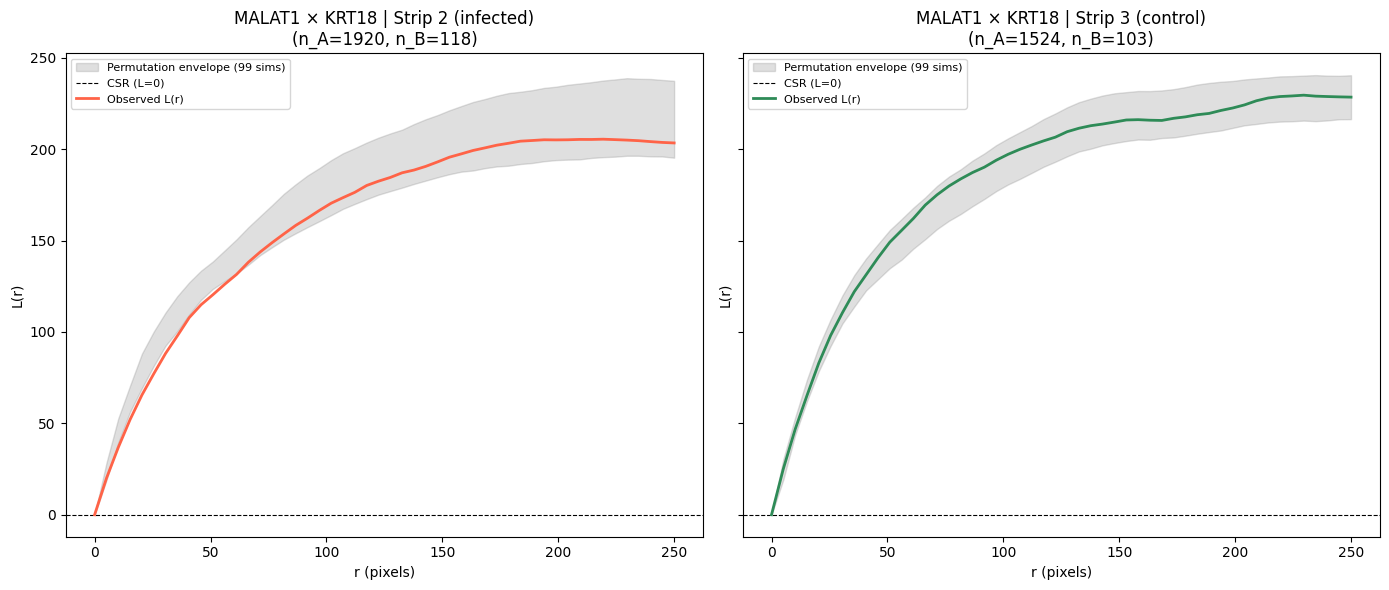

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

strip_labels = {
    'strip_2': 'Strip 2 (infected)',
    'strip_3': 'Strip 3 (control)',
}
strip_colors = {
    'strip_2': 'tomato',
    'strip_3': 'seagreen',
}

for ax, strip_name in zip(axes, ['strip_2', 'strip_3']):
    res = results[strip_name]
    
    # Envelope (shaded region = range of null simulations)
    ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
                    alpha=0.25, color='grey', label='Permutation envelope (99 sims)')
    
    # CSR baseline
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='CSR (L=0)')
    
    # Observed
    ax.plot(r_vals, res['l_obs'], color=strip_colors[strip_name],
            linewidth=2, label=f'Observed L(r)')
    
    ax.set_xlabel('r (pixels)')
    ax.set_ylabel('L(r)')
    ax.set_title(f"{GENE_A} × {GENE_B} | {strip_labels[strip_name]}\n"
                 f"(n_A={res['n_a']}, n_B={res['n_b']})")
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/05_Lfunction_KRT8_MALAT1_by_strip.png', dpi=150, bbox_inches='tight')
plt.show()

### Results analysis
- L(r) values are well within the permutation envelope, meaning we cannot reject the null
- "Gene-label specific interactions are not significant in the co-occurance of these two genes"
- The co-occurance is due to shared tissue stricture and spatial distribution, not gene-specific co-localisation


### The genes we have to work with in these two strips
Genes usable in strip_2 and strip_3 (16):
 strip     strip_2  strip_3
target                    
MALAT1       1920     1524
NEAT1         449      549
PPIA          349      290
RPL21         230      253
SCGB3A1       200       82
HMGN2         132      134
KRT18         118      103
RPL34         106       95
TPT1          105       53
RPL32          91       88
MHC I          90      100
RPL22          83       70
KRT8           74       70
RPL37          72       50
KRT19          64       87
EIF5A/L1       52       50

MALAT1, NEAT1, PPIA, RPL21, HMGN2, RPL34, TPT1, RPL32, RPL22, RPL37, EIF5A/L1 are all housekeeping/ubiquitous genes. Ribosomal proteins, nucleae lncRNAs, translation factors - expressed in almost every cell (bad nagative controls because they will co-localise with everything).

KRT8, KRT18, KRT19 are all epithelial markers. These are keratins expressed in the same simple epithelial cells. Co-localise strongly with each other - label specific (positive control)

That leaves SCGB3A1 and MHC I. 

SCGB3A1 is a secretory cell marker, and is expressed specifically in club cells and goblet cells in the airways. 

MHC I is a broad immune/antigen presentation marker expressed across many cell types but particularly enriched on immune cells and antigen-presenting cells.

**The best negative control pair from this list is KRT8 × SCGB3A1**

KRT8 marks simple epithelial cells. SCGB3A1 marks secretry airway cells. These are distinct from one anotehr and so should occupy different anatomical compartments within the lung (alveolar vs airway). We should expect their transcripts to be in physically separate regions. 

## REAL Negative Control Test: KRT8 c SCGB3A1


  Processing strip_2


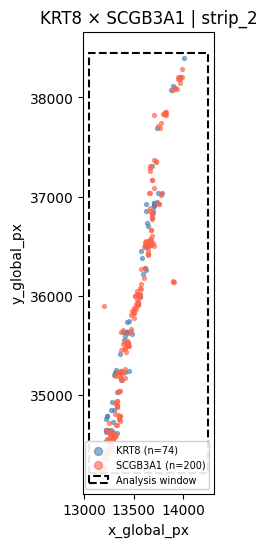

  KRT8: 74 transcripts
  SCGB3A1: 200 transcripts
  Window: x=[13052, 14252], y=[34219, 38450]
  Narrowest dimension: 1200 px
  R_MAX = 250 px (21% of narrow dim)
  Observed L(r) computed in 0.0s
    L(r=50): 126.15
    L(r=100): 184.23
    L(r=200): 208.99
  Computing 99-simulation envelope (this will take ~2s)...
  Envelope computed in 1.7s

  Processing strip_3


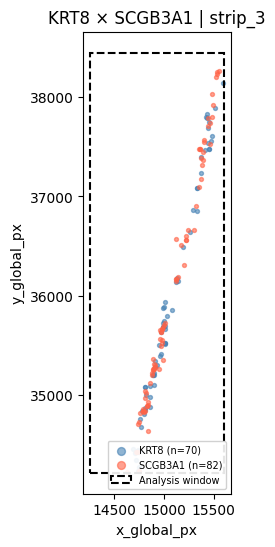

  KRT8: 70 transcripts
  SCGB3A1: 82 transcripts
  Window: x=[14254, 15605], y=[34219, 38448]
  Narrowest dimension: 1351 px
  R_MAX = 250 px (19% of narrow dim)
  Observed L(r) computed in 0.0s
    L(r=50): 179.00
    L(r=100): 225.20
    L(r=200): 255.42
  Computing 99-simulation envelope (this will take ~1s)...
  Envelope computed in 0.7s


In [30]:
GENE_A = 'KRT8'
GENE_B = 'SCGB3A1'

DIAGNOSTICS = True

results = {}

for strip_name in ['strip_2', 'strip_3']:
    print(f"\n{'='*60}")
    print(f"  Processing {strip_name}")
    print(f"{'='*60}")
    
    strip_df = fov3[fov3['strip'] == strip_name]
    
    coords_a = get_coords(strip_df, GENE_A)
    coords_b = get_coords(strip_df, GENE_B)
    window   = get_window(strip_df)
    
    if DIAGNOSTICS:
        plot_diagnostics(coords_a, coords_b, window,
                     gene_a=GENE_A, gene_b=GENE_B,
                     title=f'{GENE_A} × {GENE_B} | {strip_name}')
        plt.show()

    n_a, n_b = len(coords_a), len(coords_b)
    narrow_dim = min(window[1] - window[0], window[3] - window[2])
    
    print(f"  {GENE_A}: {n_a} transcripts")
    print(f"  {GENE_B}: {n_b} transcripts")
    print(f"  Window: x=[{window[0]:.0f}, {window[1]:.0f}], "
          f"y=[{window[2]:.0f}, {window[3]:.0f}]")
    print(f"  Narrowest dimension: {narrow_dim:.0f} px")
    print(f"  R_MAX = {R_MAX} px ({R_MAX/narrow_dim*100:.0f}% of narrow dim)")
    
    # --- Observed L(r) ---
    t0 = time.time()
    k_obs = bivariate_k(coords_a, coords_b, r_vals, window)
    l_obs = k_to_l(k_obs, r_vals)
    t_obs = time.time() - t0
    print(f"  Observed L(r) computed in {t_obs:.1f}s")
    
    # Spot-check
    for r_check in [50, 100, 200]:
        idx = np.argmin(np.abs(r_vals - r_check))
        print(f"    L(r={r_check}): {l_obs[idx]:.2f}")
    
    # --- Permutation envelope ---
    print(f"  Computing {N_SIM}-simulation envelope (this will take ~{t_obs * N_SIM:.0f}s)...")
    t0 = time.time()
    l_lo, l_hi = compute_envelope(coords_a, coords_b, r_vals, window,
                                   n_sim=N_SIM, seed=SEED)
    t_env = time.time() - t0
    print(f"  Envelope computed in {t_env:.1f}s")
    
    # Store everything
    results[strip_name] = {
        'coords_a': coords_a,
        'coords_b': coords_b,
        'window': window,
        'k_obs': k_obs,
        'l_obs': l_obs,
        'l_lo': l_lo,
        'l_hi': l_hi,
        'n_a': n_a,
        'n_b': n_b,
    }

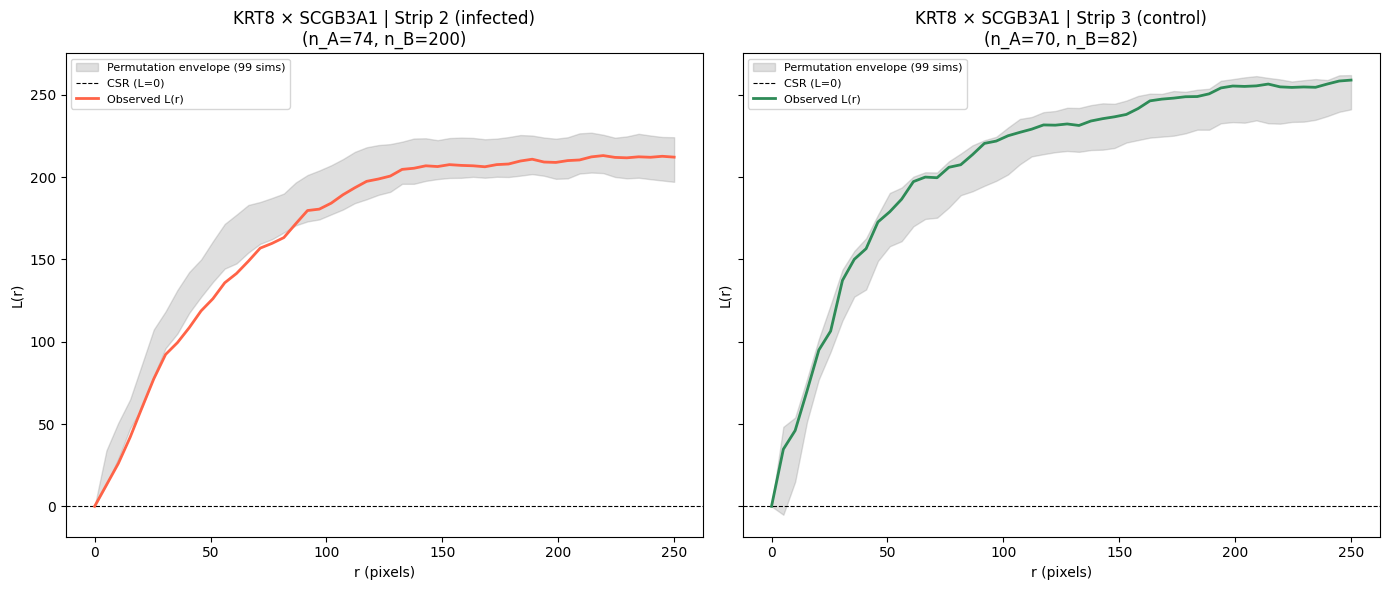

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

strip_labels = {
    'strip_2': 'Strip 2 (infected)',
    'strip_3': 'Strip 3 (control)',
}
strip_colors = {
    'strip_2': 'tomato',
    'strip_3': 'seagreen',
}

for ax, strip_name in zip(axes, ['strip_2', 'strip_3']):
    res = results[strip_name]
    
    # Envelope (shaded region = range of null simulations)
    ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
                    alpha=0.25, color='grey', label='Permutation envelope (99 sims)')
    
    # CSR baseline
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='CSR (L=0)')
    
    # Observed
    ax.plot(r_vals, res['l_obs'], color=strip_colors[strip_name],
            linewidth=2, label=f'Observed L(r)')
    
    ax.set_xlabel('r (pixels)')
    ax.set_ylabel('L(r)')
    ax.set_title(f"{GENE_A} × {GENE_B} | {strip_labels[strip_name]}\n"
                 f"(n_A={res['n_a']}, n_B={res['n_b']})")
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/05_Lfunction_KRT8_SCGB3A1_by_strip.png', dpi=150, bbox_inches='tight')
plt.show()

The key insight is: in narrow tissue strips, raw L(r) magnitude is dominated by tissue geometry and will be high for almost any gene pair. The permutation envelope is therefore essential —  it's the only way to distinguish gene-specific co-localisation from spatial coincidence in this data structure